In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('netflix.csv')
print("Shape : ", df.shape)

Shape :  (1000, 7)


In [7]:
print('First five rows :')
display(df.head())

First five rows :


,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80


In [8]:
print('Last five rows : ')
display(df.tail())

Last five rows : 


,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
995,The BFG,PG,"for action/peril, some scary moments and brief...",60,2016,97.0,80
996,The Secret Life of Pets,PG,for action and some rude humor,60,2016,NaN,81
997,Precious Puppies,TV-G,Suitable for all ages.,35,2003,NaN,82
998,Beary Tales,TV-G,Suitable for all ages.,35,2013,NaN,82
999,Growing Up Wild,G,NaN,35,2016,80.0,80


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   object 
 1   rating             1000 non-null   object 
 2   ratinglevel        941 non-null    object 
 3   ratingdescription  1000 non-null   int64  
 4   release_year       1000 non-null   int64  
 5   user_rating_score  605 non-null    float64
 6   user_rating_size   1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [10]:
df.describe(include='all')

,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
count,1000,1000,941,1000.00000,1000.000000,605.000000,1000.000000
unique,496,13,99,NaN,NaN,NaN,NaN
top,13 Reasons Why,TV-14,Parents strongly cautioned. May be unsuitable ...,NaN,NaN,NaN,NaN
freq,8,234,224,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,67.36600,2010.335000,84.094215,80.783000
std,NaN,NaN,NaN,30.78561,8.877927,12.344371,0.973066
min,NaN,NaN,NaN,10.00000,1940.000000,55.000000,80.000000
25%,NaN,NaN,NaN,35.00000,2007.000000,75.000000,80.000000
50%,NaN,NaN,NaN,60.00000,2015.000000,88.000000,80.000000
75%,NaN,NaN,NaN,90.00000,2016.000000,95.000000,82.000000


In [11]:
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
missing_df = pd.DataFrame({'Missing Count' : missing, 'Missing %' : missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                   Missing Count  Missing %
ratinglevel                   59        5.9
user_rating_score            395       39.5


In [13]:
df['ratinglevel'] = df['ratinglevel'].fillna('Not Specified')
df['user_rating_score'] = df['user_rating_score'].fillna(df['user_rating_score'].median())

print(df.isnull().sum())

title                0
rating               0
ratinglevel          0
ratingdescription    0
release_year         0
user_rating_score    0
user_rating_size     0
dtype: int64


In [15]:
print("Duplicate rows : " , df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after : ", df.shape)

Duplicate rows :  500
Shape after :  (500, 7)


In [19]:
print(df.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['title', 'rating', 'ratinglevel', 'ratingdescription', 'release_year',
       'user_rating_score', 'user_rating_size'],
      dtype='object')>


/tmp/ipykernel_1261/3799725176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')


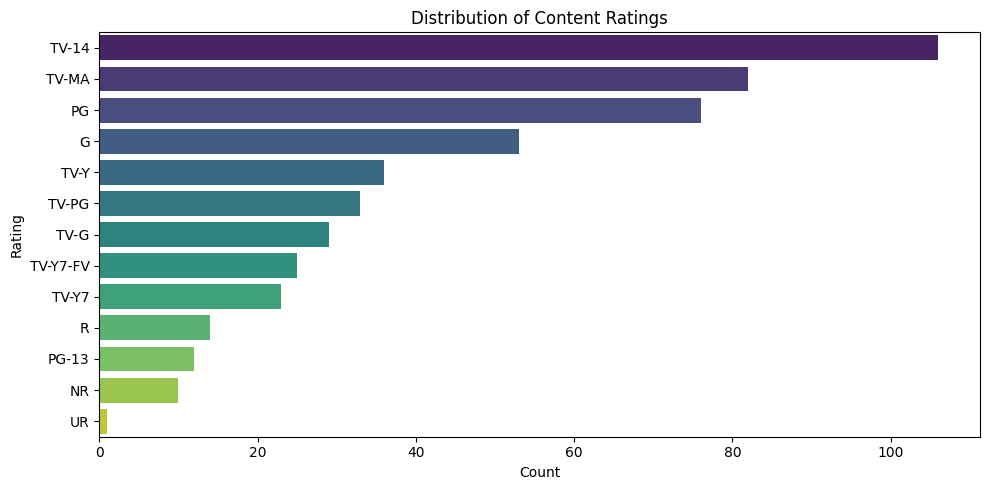

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')
plt.title('Distribution of Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

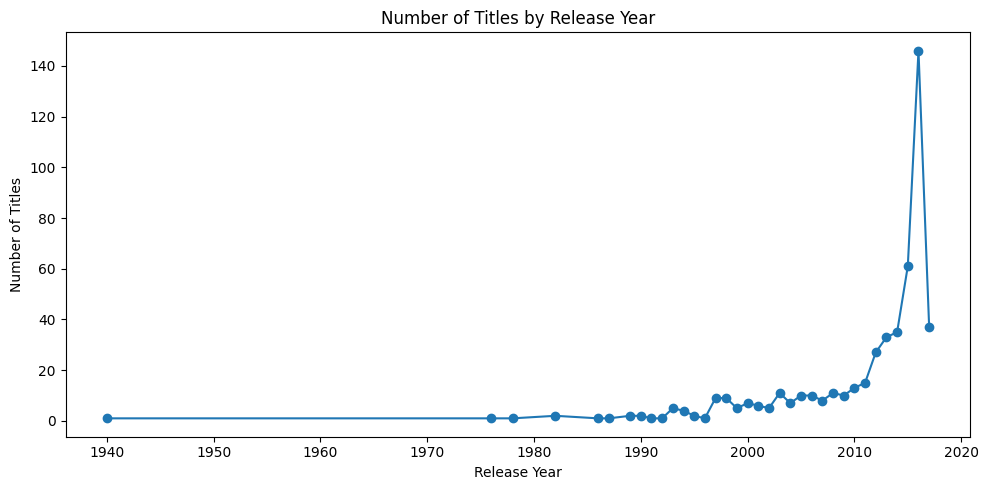

In [21]:
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Number of Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

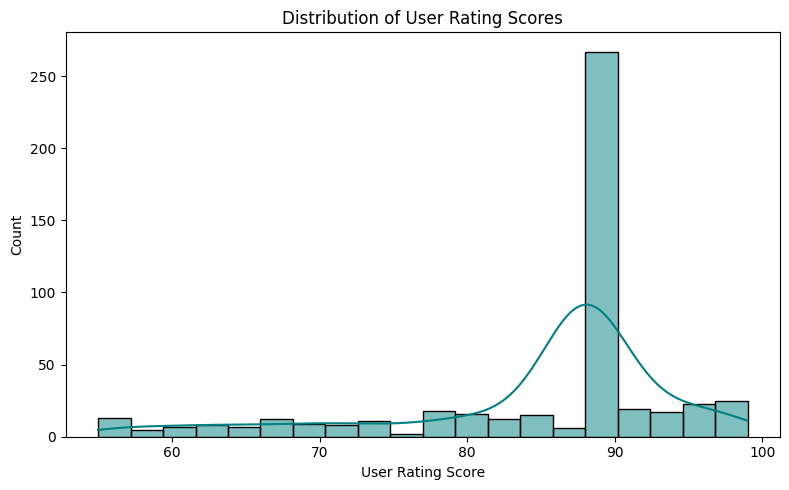

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['user_rating_score'], bins=20, kde=True, color='teal')
plt.title('Distribution of User Rating Scores')
plt.xlabel('User Rating Score')
plt.tight_layout()
plt.show()

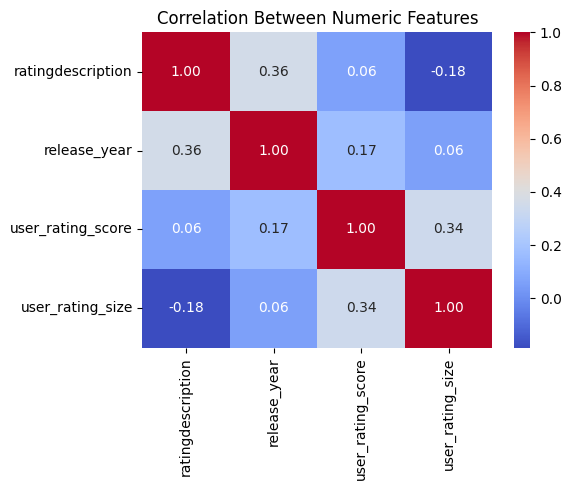

In [23]:
plt.figure(figsize=(6,5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

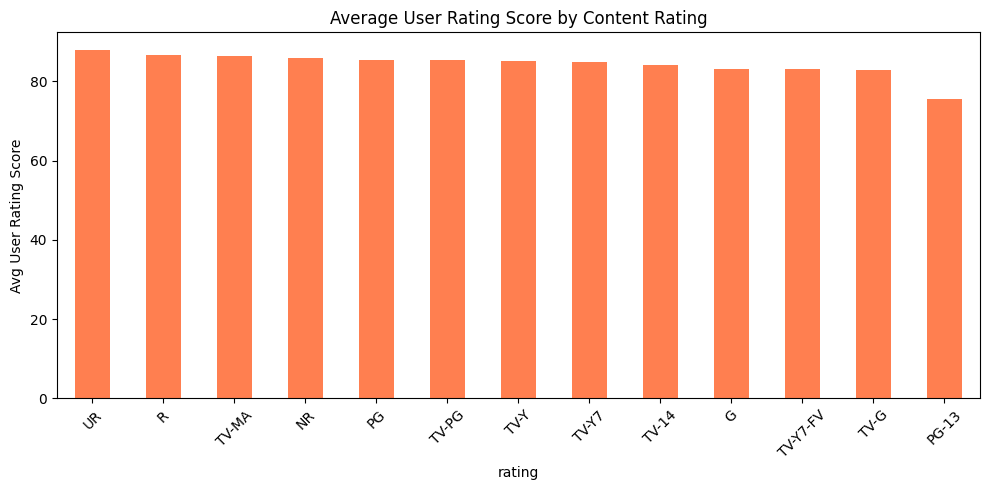

In [24]:
plt.figure(figsize=(10,5))
avg_by_rating = df.groupby('rating')['user_rating_score'].mean().sort_values(ascending=False)
avg_by_rating.plot(kind='bar', color='coral')
plt.title('Average User Rating Score by Content Rating')
plt.ylabel('Avg User Rating Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

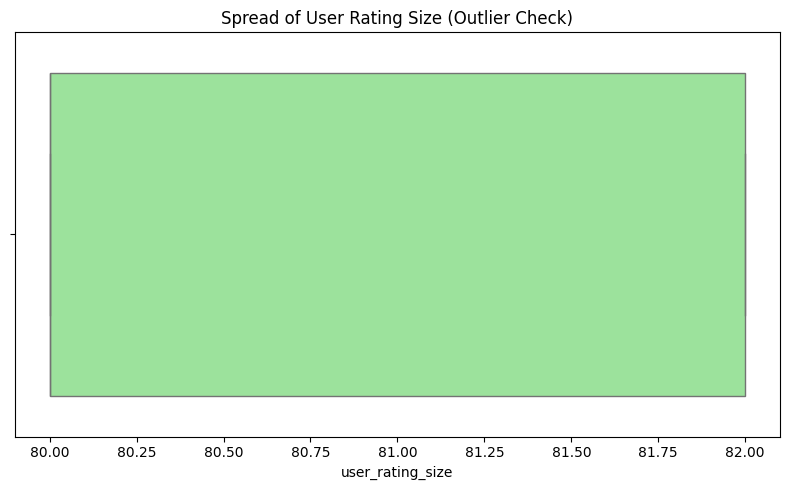

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['user_rating_size'], color='lightgreen')
plt.title('Spread of User Rating Size (Outlier Check)')
plt.tight_layout()
plt.show()